<a href="https://colab.research.google.com/github/sommernesto/GreenGrid-Predictor/blob/develop/notebooks/GreenGridFinalAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
# CELL 1 — Imports & setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

os.makedirs("plots", exist_ok=True)
os.makedirs("data", exist_ok=True)
plt.style.use('seaborn-v0_8')
%matplotlib inline
print("All imports ready")

All imports ready


In [8]:
# CELL 2 — Upload your solar CSV
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
!mv "{filename}" "data/spain_solar_2020_2024.csv"
print("Solar data saved")

Saving spain_renewables_master_2020_2024 .csv to spain_renewables_master_2020_2024  (1).csv
Solar data saved


In [9]:
# CELL 3 — Download weather data (2020–2024) for Madrid
!pip install openmeteo-requests requests-cache retry-requests -q

import openmeteo_requests
import requests_cache
from retry_requests import retry

cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 40.4168, "longitude": -3.7038,
    "start_date": "2020-01-01", "end_date": "2024-12-31",
    "hourly": ["temperature_2m", "cloud_cover"],
    "timezone": "Europe/Berlin"
}
responses = openmeteo.weather_api(url, params=params)
response = responses[0]

hourly = response.Hourly()
weather_df = pd.DataFrame({
    "timestamp": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s"),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s"),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ),
    "temperature": hourly.Variables(0).ValuesAsNumpy(),
    "cloud_cover": hourly.Variables(1).ValuesAsNumpy()
})
weather_df.set_index("timestamp", inplace=True)  # FIXED: Add this line
weather_df.to_csv("weather_madrid_2020_2024.csv")  # FIXED: Add this line
print("Weather data saved → 43,824 hourly rows")
weather_df.tail()

Weather data saved → 43,824 hourly rows


,temperature,cloud_cover
timestamp,,
2024-12-31 18:00:00,4.305,0.0
2024-12-31 19:00:00,3.255,0.0
2024-12-31 20:00:00,1.955,0.0
2024-12-31 21:00:00,1.355,0.0
2024-12-31 22:00:00,1.155,0.0


In [11]:
# CELL 4 — Load solar + merge weather
df = pd.read_csv("data/spain_solar_2020_2024.csv")
df = df[['timestamp', 'solar_mw']].copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Merge weather
weather = pd.read_csv("weather_madrid_2020_2024.csv", parse_dates=['timestamp'])
weather.set_index('timestamp', inplace=True)
df = df.join(weather, how='left')

print(f"Shape with weather: {df.shape}")
df.tail()

Shape with weather: (43848, 3)


,solar_mw,temperature,cloud_cover
timestamp,,,
2024-12-31 19:00:00,153.0,3.255,0.0
2024-12-31 20:00:00,150.0,1.955,0.0
2024-12-31 21:00:00,32.0,1.355,0.0
2024-12-31 22:00:00,5.0,1.155,0.0
2024-12-31 23:00:00,4.0,NaN,NaN


In [12]:
# CELL 5 — Sanity check (run to verify merge)
print("Columns:", df.columns.tolist())
print("\nMissing values in weather:")
print(df[['temperature', 'cloud_cover']].isna().sum())
print("\nSample data:")
display(df[['solar_mw', 'temperature', 'cloud_cover']].tail())

Columns: ['solar_mw', 'temperature', 'cloud_cover']

Missing values in weather:
temperature    1
cloud_cover    1
dtype: int64

Sample data:


,solar_mw,temperature,cloud_cover
timestamp,,,
2024-12-31 19:00:00,153.0,3.255,0.0
2024-12-31 20:00:00,150.0,1.955,0.0
2024-12-31 21:00:00,32.0,1.355,0.0
2024-12-31 22:00:00,5.0,1.155,0.0
2024-12-31 23:00:00,4.0,NaN,NaN


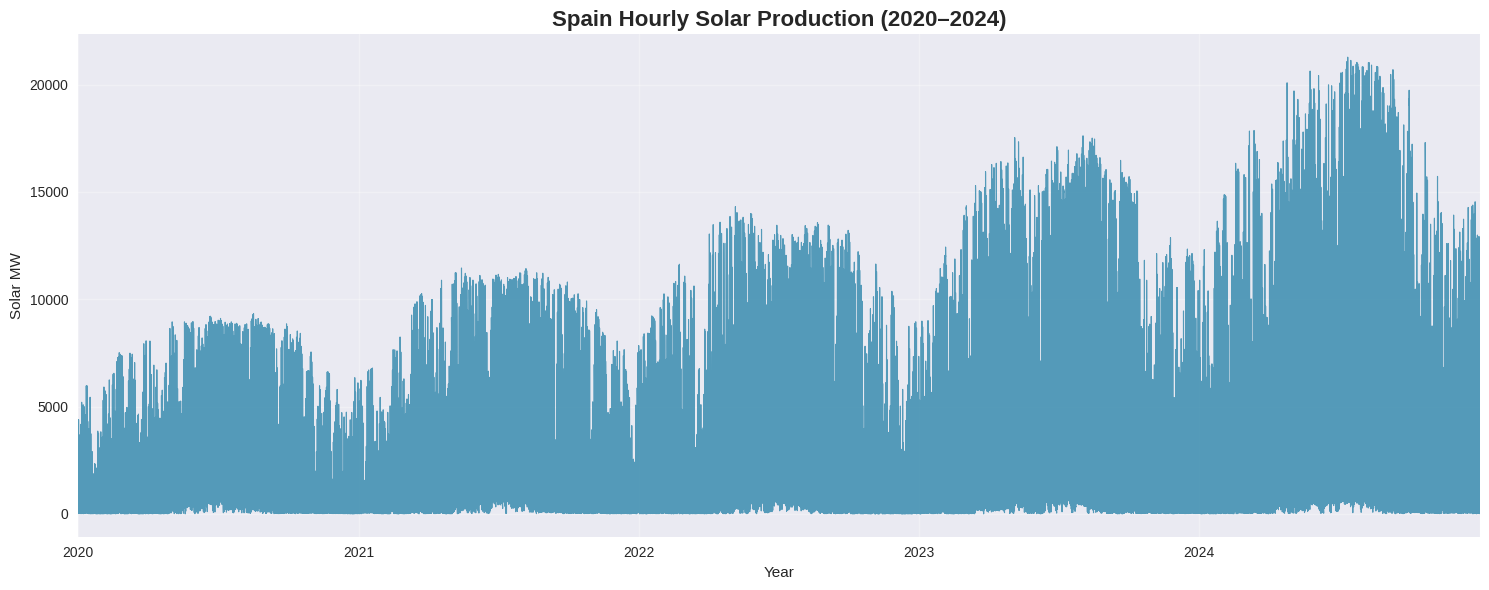

In [13]:
# CELL 6 — EDA plot (full time series)
fig, ax = plt.subplots(figsize=(15, 6))
df['solar_mw'].plot(ax=ax, linewidth=0.8, alpha=0.8, color='#2E86AB')
ax.set_title('Spain Hourly Solar Production (2020–2024)', fontsize=16, fontweight='bold')
ax.set_ylabel('Solar MW')
ax.set_xlabel('Year')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/01_full_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# CELL 7 — Train/test split + baseline
train = df[df.index.year <= 2023]
test  = df[df.index.year == 2024]

print(f"Train: {train.shape[0]:,} rows | Test: {test.shape[0]:,} rows")

# Persistence baseline
test_baseline = test.shift(24)
baseline_mae = np.mean(np.abs(test['solar_mw'] - test_baseline['solar_mw'].dropna()))
baseline_rmse = np.sqrt(np.mean((test['solar_mw'] - test_baseline['solar_mw'].dropna())**2))

print(f"Baseline MAE: {baseline_mae:.1f} MW | RMSE: {baseline_rmse:.1f} MW")

Train: 35,064 rows | Test: 8,784 rows
Baseline MAE: 921.7 MW | RMSE: 1749.0 MW


In [15]:
# CELL 8 — Feature engineering + XGBoost (with weather)
def create_features(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['lag_24'] = df['solar_mw'].shift(24)
    df['lag_48'] = df['solar_mw'].shift(48)
    df['rolling_mean_24'] = df['solar_mw'].rolling(24).mean()
    # Weather features
    df['temperature'] = df['temperature']
    df['cloud_cover'] = df['cloud_cover']
    return df.dropna()

model_df = create_features(df)
train_df = model_df[model_df.index.year <= 2023]
test_df = model_df[model_df.index.year == 2024]

features = ['hour', 'day_of_week', 'month', 'lag_24', 'lag_48', 'rolling_mean_24', 'temperature', 'cloud_cover']
X_train, y_train = train_df[features], train_df['solar_mw']
X_test, y_test = test_df[features], test_df['solar_mw']

model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
model.fit(X_train, y_train, verbose=False)

pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print(f"XGBoost with Weather → MAE: {mae:.1f} MW | RMSE: {rmse:.1f} MW")
print(f"Improvement over baseline: {100*(baseline_mae - mae)/baseline_mae:.1f}% better")

XGBoost with Weather → MAE: 755.0 MW | RMSE: 1309.7 MW
Improvement over baseline: 18.1% better


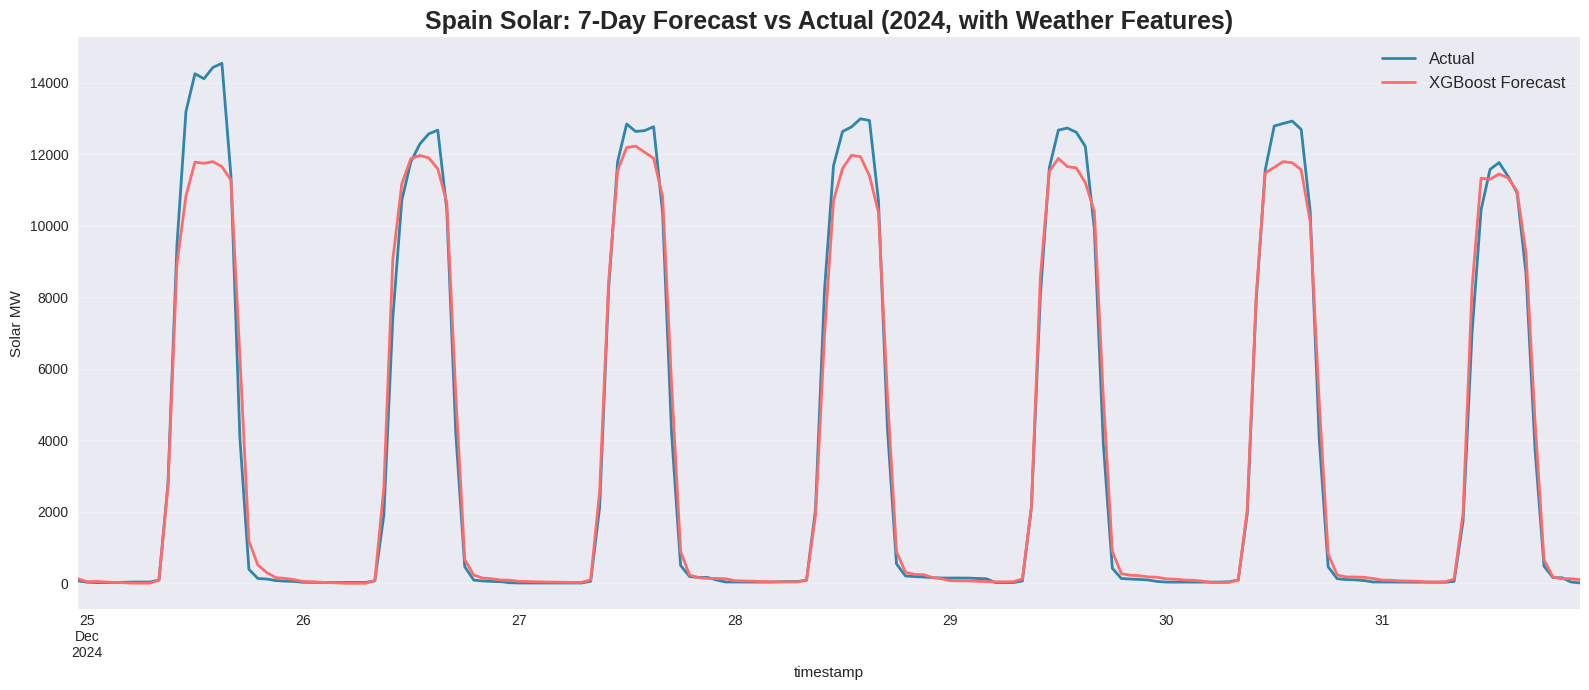

,Model,MAE (MW),RMSE (MW)
0,Persistence Baseline,921.736644,1748.970355
1,XGBoost (with Weather),754.950286,1309.722275


In [16]:
# CELL 9 — Forecast plot + results CSV
fig, ax = plt.subplots(figsize=(16, 7))
plot_df = test_df[-7*24:].copy()
plot_df['prediction'] = pred[-7*24:]

plot_df['solar_mw'].plot(ax=ax, label='Actual', linewidth=2, color='#2E86AB')
plot_df['prediction'].plot(ax=ax, label='XGBoost Forecast', linewidth=2, color='#ff6b6b')

ax.set_title('Spain Solar: 7-Day Forecast vs Actual (2024, with Weather Features)', fontsize=18, fontweight='bold')
ax.set_ylabel('Solar MW')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/02_xgboost_forecast_7days.png', dpi=300, bbox_inches='tight')
plt.show()

# Results table
results = pd.DataFrame({
    'Model': ['Persistence Baseline', 'XGBoost (with Weather)'],
    'MAE (MW)': [baseline_mae, mae],
    'RMSE (MW)': [baseline_rmse, rmse]
})
results.to_csv('plots/model_comparison.csv', index=False)
results